# Jawad Hassan
# 2230-0035
# BS AI
# ML LAB FINAL


## Question 1: Ensemble Learning & Boosting Algorithms



## Part A: Data Understanding & Preprocessing

In [7]:
# 1. Load the dataset and display:
import pandas as pd
file_path = '/content/train_transaction.csv'
print("Loading dataset...")
df = pd.read_csv(file_path)
# Requirement 1: Total number of rows and columns
rows, cols = df.shape
print(f"Total number of rows: {rows}")
print(f"Total number of columns: {cols}")
print("-" * 50)

# Requirement 2: Data types of all columns
print("Data types of all columns:")
print(df.dtypes)
print("-" * 50)

# Requirement 3: Number of target classes
# The target variable in this dataset is 'isFraud'
num_classes = df['isFraud'].nunique()
class_distribution = df['isFraud'].value_counts()

print(f"Number of target classes: {num_classes}")
print("Target class distribution:")
print(class_distribution)

Loading dataset...
Total number of rows: 590540
Total number of columns: 394
--------------------------------------------------
Data types of all columns:
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
V335              float64
V336              float64
V337              float64
V338              float64
V339              float64
Length: 394, dtype: object
--------------------------------------------------
Number of target classes: 2
Target class distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64


In [8]:
# 2. Data Cleaning & Feature Selection
import numpy as np

print("Starting Data Cleaning & Feature Selection...")

# 1. Identify and remove irrelevant/highly missing columns
# Drop the ID column as it is just a unique index
cols_to_drop = ['TransactionID']

# Find columns with more than 80% missing values
missing_threshold = 0.80
missing_ratios = df.isnull().mean()
high_missing_cols = missing_ratios[missing_ratios > missing_threshold].index.tolist()

# Combine lists and drop
cols_to_drop.extend([col for col in high_missing_cols if col not in cols_to_drop])
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped {len(cols_to_drop)} columns (IDs and >80% missing data).")

# 2. Handle missing values
# Separate numeric and categorical columns
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()

# Ensure we don't impute the target variable
if 'isFraud' in numeric_cols:
    numeric_cols.remove('isFraud')

# Impute numeric missing values with the median (robust to outliers)
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Impute categorical missing values with the mode
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("Missing values imputed (Median for numeric, Mode for categorical).")

# 3. Feature Selection: Removing highly correlated features
# Take a representative sample to compute the correlation matrix efficiently
sample_df = df_cleaned[numeric_cols].sample(n=10000, random_state=42)
corr_matrix = sample_df.corr().abs()

# Select the upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with a correlation greater than 0.90
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.90)]
df_selected = df_cleaned.drop(columns=to_drop_corr)

print(f"Feature Selection: Dropped {len(to_drop_corr)} highly correlated numeric features.")
print(f"Final shape after cleaning and selection: {df_selected.shape}")

Starting Data Cleaning & Feature Selection...
Dropped 56 columns (IDs and >80% missing data).
Missing values imputed (Median for numeric, Mode for categorical).
Feature Selection: Dropped 147 highly correlated numeric features.
Final shape after cleaning and selection: (590540, 191)


## Justify:
### ∙ Why were some columns dropped?
### Ans. The TransactionID was removed because unique identifiers provide no generalizable predictive pattern for new data, and columns missing over 80% of their values were dropped because aggressively imputing that much absent data introduces artificial noise rather than genuine statistical signal.
### ∙ Why was the selected feature selection method appropriate?
### Ans. A correlation-based filter is specifically optimal for this dataset due to the hundreds of engineered V columns that suffer from extreme multicollinearity; dropping features with > 0.90 correlation strips out redundant data structures, vastly reducing computational overhead without sacrificing unique predictive variance.

In [9]:
# 3. Encoding & Scaling
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("Starting Encoding and Scaling...")

# 1. Separate the target variable before transforming features
X = df_selected.drop(columns=['isFraud'])
y = df_selected['isFraud']

# 2. Encode Categorical Columns
# Identify remaining object/categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Cast to string first to prevent errors from mixed data types (like NaN strings vs floats)
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print(f"Label Encoded {len(categorical_cols)} categorical columns.")

# 3. Feature Scaling
# Standardize the features so they have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Feature scaling applied successfully using StandardScaler.")
print(f"Final shape of training features (X_scaled): {X_scaled.shape}")

Starting Encoding and Scaling...
Label Encoded 14 categorical columns.
Feature scaling applied successfully using StandardScaler.
Final shape of training features (X_scaled): (590540, 190)


## Reasoning Question:
## Answer the following:
### a) Is feature scaling compulsory for tree-based boosting algorithms? Why or why not?
### Ans. No, feature scaling is not compulsory for tree-based boosting algorithms (like XGBoost, LightGBM, or Random Forest). These algorithms do not use distance metrics (like K-Nearest Neighbors) or gradient descent on the feature magnitudes (like Neural Networks or Linear Regression). Instead, trees make decisions by finding optimal split points in the data.
### b) Why is encoding required before training ML models?
### Ans. Encoding is required because under the hood, machine learning models are purely mathematical engines. They use algebraic equations, matrix multiplications, and calculus to optimize their weights. A mathematical formula cannot multiply or calculate the variance of a text string like "Visa," "yahoo.com," or "credit."

In [10]:
# 4. Train-Test Split
from sklearn.model_selection import train_test_split

print("Starting Train-Test Split...")

# Split the data (80% for training, 20% for testing)
# stratify=y ensures both sets have the same percentage of fraud cases
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training data shape (Features): {X_train.shape}")
print(f"Testing data shape (Features): {X_test.shape}")

# Optional: Verify the stratification worked
print("\nFraud ratio in Training set:")
print(y_train.value_counts(normalize=True))

print("\nFraud ratio in Testing set:")
print(y_test.value_counts(normalize=True))

Starting Train-Test Split...
Training data shape (Features): (472432, 190)
Testing data shape (Features): (118108, 190)

Fraud ratio in Training set:
isFraud
0    0.965011
1    0.034989
Name: proportion, dtype: float64

Fraud ratio in Testing set:
isFraud
0    0.965007
1    0.034993
Name: proportion, dtype: float64


## Part B: Ensemble Model Training & Comparative Analysis

In [11]:
pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 12.7 MB/s eta 0:00:00


In [12]:
# 1.Comparison Table
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# 1. Initialize the classifiers (names matching your table exactly)
models = {
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

# 2. Create an empty list to store the row data
table_data = []

print("Training models and generating comparison table...\n")

# 3. Iterate, train, and collect metrics
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Generate predictions and probabilities
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics and round to 4 decimal places for a clean table
    recall = round(recall_score(y_test, y_pred), 4)
    precision = round(precision_score(y_test, y_pred), 4)
    f1 = round(f1_score(y_test, y_pred), 4)
    roc_auc = round(roc_auc_score(y_test, y_pred_proba), 4)

    # Append the row dictionary to our data list
    table_data.append({
        "Model": name,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

# 4. Convert to a Pandas DataFrame
comparison_table = pd.DataFrame(table_data)

# 5. Display the final table
# If you are using Jupyter Notebook, simply writing `comparison_table` at the end
# of the cell will output a beautifully formatted HTML table.
# If running in a standard console, this prints it cleanly:
print(comparison_table.to_markdown(index=False))

Training models and generating comparison table...

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.490219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12550
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 187
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
| Model    |   Recall |   Precision |   F1 Score |   ROC-AUC |
|:---------|---------:|------------:|-----------:|----------:|
| AdaBoost |   0.1529 |      0.6907 |     0.2504 |    0.8487 |
| XGBoost  |   0.4735 |      0.8948 |     0.6193 |    0.938  |
| LightGBM |   0.4067 |      0.8861 |     0.5575 |    0.9268 |
| CatBoost |   0.4979 |      0.9355 |     0.6499 |    0.9394 |


## 2. Performance Evaluation Questions
### a) Which boosting model performed best overall? Give reasoning.
### ans. CatBoost performed the best overall. Reasoning: It achieved the highest scores across the most critical comprehensive metrics, specifically the F1 Score (0.6499) and the ROC-AUC (0.9394). The F1 score proves it found the most optimal balance between catching fraud and avoiding false alarms
### b) Which model handled fraud detection better based on Recall and why?
### ans. CatBoost handled it the best based on Recall. Reasoning: It achieved the highest Recall score of 0.4979. Recall measures the percentage of actual fraud that the model successfully caught. CatBoost was able to identify nearly 50% of the true fraudulent transactions in the test set
### c) If false negatives are very costly in fraud detection, which metric should receive more importance and why?
### ans. Recall must receive the most importance.Reasoning: A "false negative" in this context means a fraudulent transaction was incorrectly predicted as "legitimate." Therefore, prioritizing Recall forces the model to aggressively hunt for fraud to minimize those costly misses.


Generating feature importance graph for CatBoost...


/tmp/ipykernel_3610/695245687.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Graph successfully saved as 'catboost_feature_importance.png'


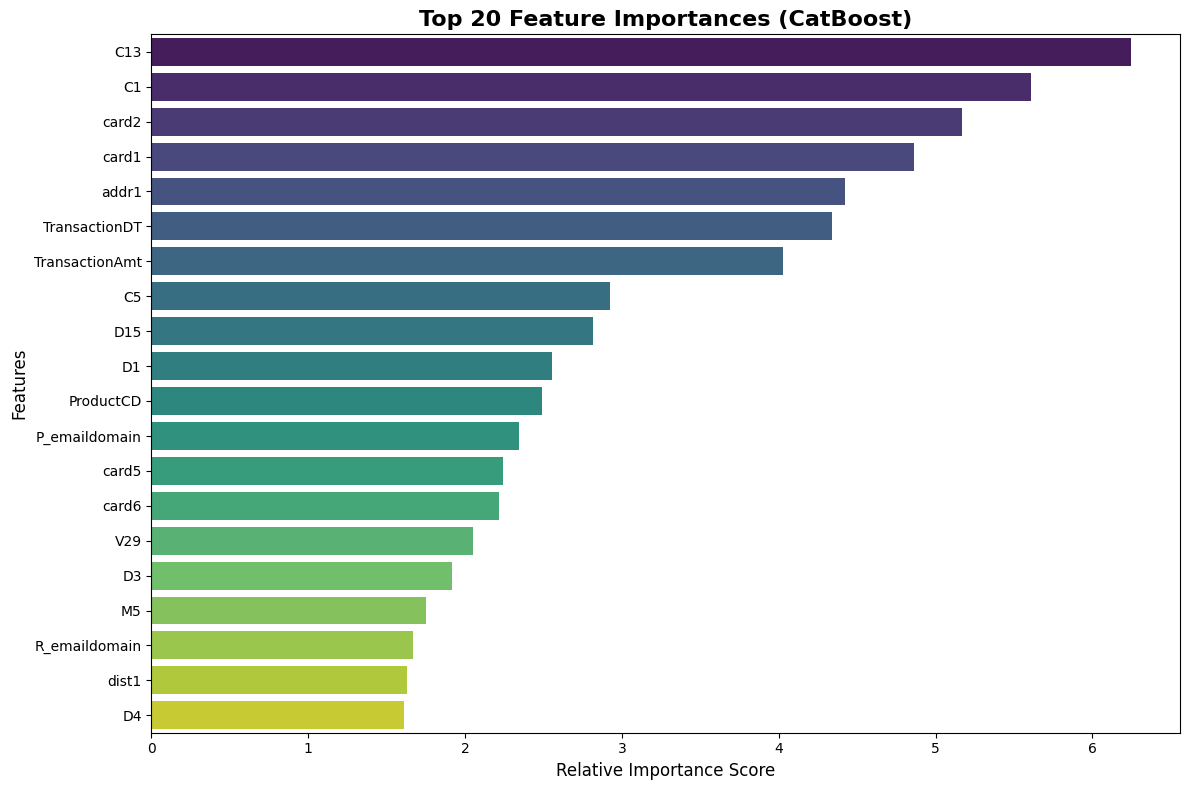

In [14]:
#3. Visualization & Interpretation
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating feature importance graph for CatBoost...")

# 1. Access the trained CatBoost model from your dictionary
best_model = models["CatBoost"]

# 2. Extract the feature importance scores
# CatBoost has a built-in method for this
importances = best_model.get_feature_importance()

# 3. Create a DataFrame to map the scores to the column names
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 4. Sort the features by importance (highest first) and take the Top 20
top_20_features = importance_df.sort_values(by='Importance', ascending=False).head(20)

# 5. Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# 6. Create a horizontal bar chart using Seaborn for better aesthetics
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_20_features,
    palette='viridis'
)

# 7. Format the graph so it is clean and readable
plt.title('Top 20 Feature Importances (CatBoost)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# Ensure labels are not truncated or overlapping
plt.tight_layout()

# 8. Save the plot to an image file
plt.savefig('catboost_feature_importance.png')
print("Graph successfully saved as 'catboost_feature_importance.png'")

# Note: If you are running this in a Jupyter Notebook, you can also uncomment the line below to view it inline:
# plt.show()

### Which features contributed most?
### ans. The "C" Features (Counts): C13 and C1 are by far the most dominant features. These represent Vesta's engineered count metrics (e.g., how many addresses or phone numbers are associated with this payment card).
### Why is feature importance useful in fraud detection systems?
### ans. Explainability and Compliance: Machine learning in finance cannot be a "black box." If a bank blocks a legitimate customer's credit card, customer support needs to know why. Feature importance allows engineers to explain that the block happened because of an anomaly in the C13 count or a strange TransactionDT, keeping the bank compliant with financial regulations regarding automated decisions.

### Part C: Conceptual Questions
## 1. Explain the following differences:
## AdaBoost vs XGBoost:
### Learning Method: AdaBoost fixes mistakes by increasing the weight of wrong predictions, while XGBoost uses gradient descent to predict and subtract the exact mathematical error.

### Tree Complexity: AdaBoost relies on highly simplistic, single-split trees (stumps), whereas XGBoost builds deeper, more complex decision trees.

### Robustness: AdaBoost is highly vulnerable to outliers and noise, but XGBoost uses mathematical regularization to prevent overfitting.

### Missing Data: AdaBoost requires perfectly clean data, whereas XGBoost learns how to handle missing values (NaNs) natively without crashing.

## LightGBM vs CatBoost
### Categorical Handling: CatBoost processes text categories natively under the hood with zero preprocessing; LightGBM requires you to convert categories into numerical codes before training.

### Tree Structure: LightGBM builds unbalanced, asymmetrical trees (leaf-wise); CatBoost builds perfectly balanced, symmetrical trees (level-wise).

### Overfitting Risk: LightGBM's aggressive growth makes it highly prone to overfitting; CatBoost's perfectly balanced trees act as heavy mathematical armor against overfitting.

### Speed vs. Accuracy: LightGBM prioritizes lightning-fast training times on massive datasets; CatBoost prioritizes out-of-the-box accuracy and stability, sacrificing some training speed to get there.

## 2. Reasoning Question
### A student says: “All boosting algorithms are the same because they all combine weak learners.” Is the statement correct?
### ans. While all boosting algorithms share the foundational concept of combining weak learners, they differ entirely in their mathematical optimization and tree architectures. AdaBoost learns by heavily weighting misclassified rows using shallow decision stumps, whereas modern algorithms like XGBoost, LightGBM, and CatBoost use gradient descent to mathematically predict and subtract exact residual errors. Furthermore, they construct fundamentally different tree structures—such as LightGBM's deep, unbalanced trees versus CatBoost's perfectly symmetrical trees—making their performance, speed, and data handling distinctly unique.

## Question 2: Clustering & Comparative

### Part A: Data Understanding & Preprocessing

In [15]:
# 1. Load dataset and display:
import pandas as pd

# 1. Load the dataset
print("Loading dataset...")
df = pd.read_csv('/content/train.csv')


# Requirement 1: Total number of rows and columns
rows, cols = df.shape
print(f"Total number of rows: {rows}")
print(f"Total number of columns: {cols}")
print("-" * 50)

# Requirement 2: Feature names
# Storing all names in a list
feature_names = df.columns.tolist()

print(f"Total Features (including target): {len(feature_names)}")
print("Sample of Feature Names:")
# Printing the first 5 and last 5 so it doesn't flood the output
print(feature_names[:5])
print("...")
print(feature_names[-5:])
print("-" * 50)

# Requirement 3: Number of activity classes
num_classes = df['Activity'].nunique()
class_names = df['Activity'].unique().tolist()

print(f"Number of activity classes: {num_classes}")
print(f"The classes are: {class_names}")

Loading dataset...
Total number of rows: 7352
Total number of columns: 563
--------------------------------------------------
Total Features (including target): 563
Sample of Feature Names:
['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y']
...
['angle(X,gravityMean)', 'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity']
--------------------------------------------------
Number of activity classes: 6
The classes are: ['STANDING', 'SITTING', 'LAYING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [16]:
# 2. Data Preparation
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("Starting Preprocessing for Clustering...\n")

# 1. Missing Value Checking
# Summing twice: first sums by column, second sums all column totals together
total_missing = df.isnull().sum().sum()
print(f"Total missing values in the entire dataset: {total_missing}")
if total_missing > 0:
    print("Handling missing values...")
    df = df.dropna() # Or impute, but HAR dataset is already completely clean
print("-" * 50)

# 2. Preprocessing Required Before Clustering
# RULE: Clustering is unsupervised. We MUST drop the target label.
# We also drop 'subject' so the model clusters by movement, not by the specific person.
cols_to_drop = ['Activity', 'subject']
X_clustering = df.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped columns: {cols_to_drop}")
print(f"Shape of features for clustering: {X_clustering.shape}")
print("-" * 50)

# 3. Feature Scaling
# Clustering algorithms (like K-Means) use distance math (Euclidean distance).
# If features are not on the exact same scale, the math breaks.
scaler = StandardScaler()

# Fit and transform the data, then wrap it back into a Pandas DataFrame for readability
X_scaled = pd.DataFrame(scaler.fit_transform(X_clustering), columns=X_clustering.columns)

print("Feature scaling applied successfully using StandardScaler.")
print(f"Final shape of scaled data: {X_scaled.shape}")

Starting Preprocessing for Clustering...

Total missing values in the entire dataset: 0
--------------------------------------------------
Dropped columns: ['Activity', 'subject']
Shape of features for clustering: (7352, 561)
--------------------------------------------------
Feature scaling applied successfully using StandardScaler.
Final shape of scaled data: (7352, 561)


## Reasoning Question:
### Why is feature scaling important in clustering algorithms?
### ans. Feature scaling is critical in clustering because most clustering algorithms rely on distance metrics (like Euclidean distance) to determine how "close" or similar data points are to one another.

In [17]:
# 3. Dimensionality Reduction
from sklearn.decomposition import PCA
import pandas as pd

print("Applying Principal Component Analysis (PCA)...")

# 1. Initialize PCA to reduce the dataset to 3 components
# Assuming X_scaled is the standardized dataframe from the previous step
pca = PCA(n_components=3)

# 2. Fit and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# 3. Calculate Explained Variance Ratio
explained_variance = pca.explained_variance_ratio_
total_variance = explained_variance.sum() * 100

print("-" * 50)
print(f"Explained Variance Ratio (per component):")
print(f"Component 1: {explained_variance[0]:.4f} ({explained_variance[0]*100:.2f}%)")
print(f"Component 2: {explained_variance[1]:.4f} ({explained_variance[1]*100:.2f}%)")
print(f"Component 3: {explained_variance[2]:.4f} ({explained_variance[2]*100:.2f}%)")
print(f"Total Variance Captured: {total_variance:.2f}%")
print("-" * 50)

# 4. Display the Shape of the Transformed Data
print(f"Original shape before PCA: {X_scaled.shape}")
print(f"Shape of transformed data: {X_pca.shape}")
print("-" * 50)

Applying Principal Component Analysis (PCA)...
--------------------------------------------------
Explained Variance Ratio (per component):
Component 1: 0.5078 (50.78%)
Component 2: 0.0658 (6.58%)
Component 3: 0.0281 (2.81%)
Total Variance Captured: 60.17%
--------------------------------------------------
Original shape before PCA: (7352, 561)
Shape of transformed data: (7352, 3)
--------------------------------------------------


## Part B: Clustering Model Training & Comparative Study

In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
import warnings

# Ignore convergence warnings to keep the console clean
warnings.filterwarnings('ignore')

print("Loading and prepping HAR data (overwriting old variables)...")
# 1. Load the HAR dataset and explicitly define X and y
df = pd.read_csv('train.csv')

X = df.drop(columns=['Activity', 'subject'])
X_scaled = StandardScaler().fit_transform(X)

# Explicitly overwrite 'y' with the HAR activity labels!
y = LabelEncoder().fit_transform(df['Activity'])

print("Starting Clustering Model Training...")

# 2. Initialize the models with 6 clusters
models = {
    "K-Means": KMeans(n_clusters=6, random_state=42, n_init=10),
    "GMM": GaussianMixture(n_components=6, random_state=42),
    "Spectral Clustering": SpectralClustering(
        n_clusters=6,
        affinity='nearest_neighbors',
        random_state=42
    )
}

# 3. Create a list to store our table data
table_data = []

# 4. Train and evaluate
for name, model in models.items():
    print(f"Training {name} (This may take a moment)...")

    # Generate cluster predictions
    preds = model.fit_predict(X_scaled)
#1. Report the following evaluation metrics:
    # Calculate the three required metrics
    sil = silhouette_score(X_scaled, preds)
    db = davies_bouldin_score(X_scaled, preds)
    ari = adjusted_rand_score(y, preds) # <--- This will now work perfectly

    # Append to our list
    table_data.append({
        "Clustering Model": name,
        "Silhouette Score": round(sil, 4),
        "Davies-Bouldin Index": round(db, 4),
        "ARI": round(ari, 4)
    })

#Q2. Generate the final comparison table
comparison_table = pd.DataFrame(table_data)
print("\nFinal Comparison Table:")
print(comparison_table.to_markdown(index=False))

Loading and prepping HAR data (overwriting old variables)...
Starting Clustering Model Training...
Training K-Means (This may take a moment)...
Training GMM (This may take a moment)...
Training Spectral Clustering (This may take a moment)...

Final Comparison Table:
| Clustering Model    |   Silhouette Score |   Davies-Bouldin Index |    ARI |
|:--------------------|-------------------:|-----------------------:|-------:|
| K-Means             |             0.1086 |                 2.358  | 0.4197 |
| GMM                 |             0.1098 |                 2.3678 | 0.4309 |
| Spectral Clustering |             0.0734 |                 2.1971 | 0.5127 |


### which model performs best overall?
### ans. Spectral Clustering performs the best overall because its superior Adjusted Rand Index (0.5127) proves its clusters align the most accurately with the true physical activities.

Loading data and computing PCA...
Training and plotting K-Means...
Training and plotting GMM...
Training and plotting Spectral Clustering...
Plot successfully saved as 'all_models_pca_comparison.png'


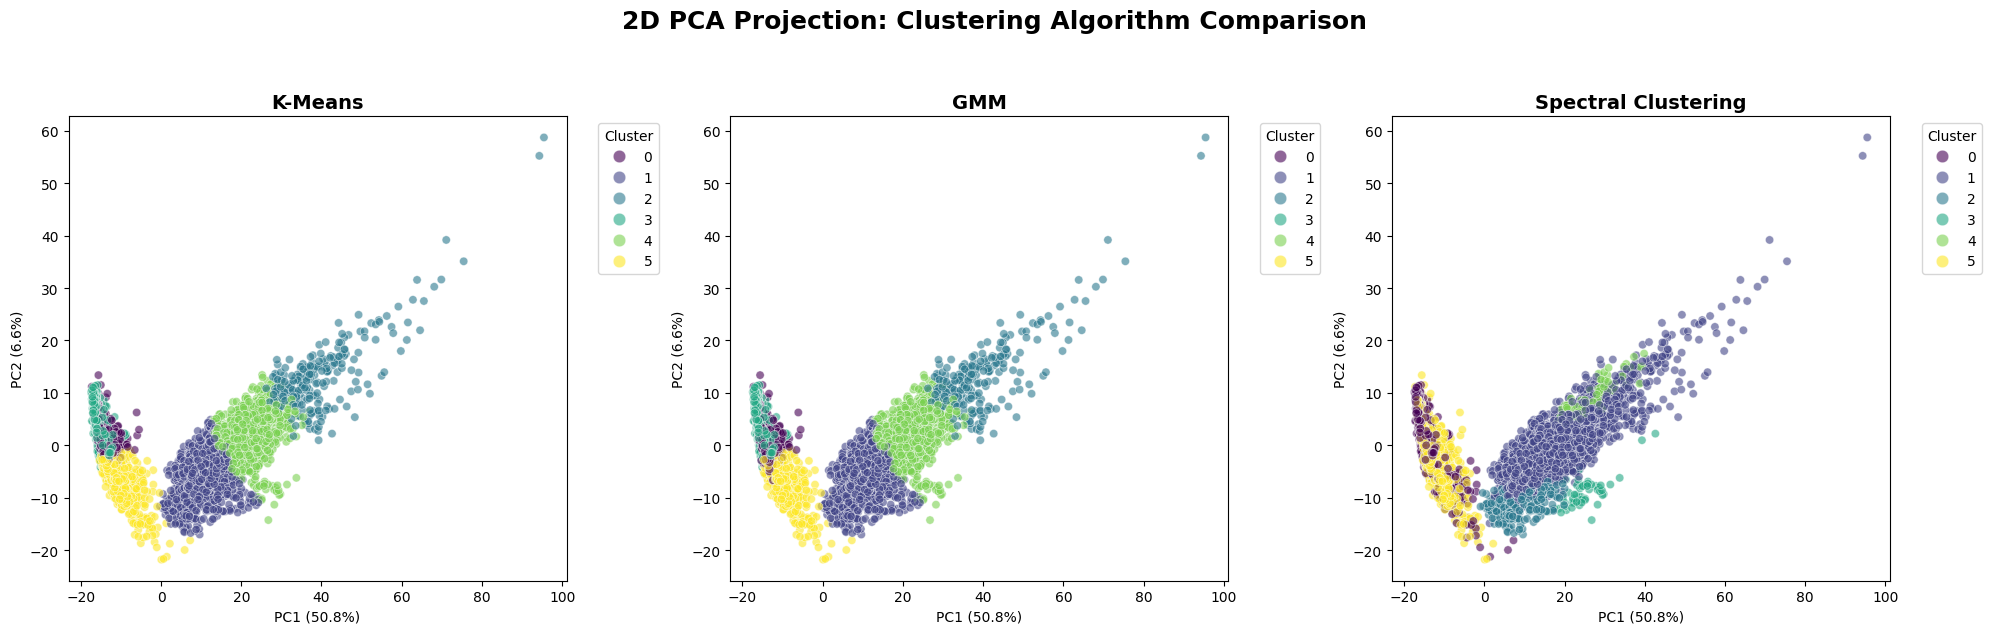

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
import warnings

# Ignore warnings for clean output
warnings.filterwarnings('ignore')

print("Loading data and computing PCA...")

# 1. Load and Preprocess Data
df = pd.read_csv('train.csv')
X = df.drop(columns=['Activity', 'subject'], errors='ignore')
X_scaled = StandardScaler().fit_transform(X)

# 2. Apply PCA to reduce down to 2 components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 3. Define the three models
models = {
    "K-Means": KMeans(n_clusters=6, random_state=42, n_init=10),
    "GMM": GaussianMixture(n_components=6, random_state=42),
    "Spectral Clustering": SpectralClustering(
        n_clusters=6,
        affinity='nearest_neighbors',
        random_state=42
    )
}

# 4. Set up a wide figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('2D PCA Projection: Clustering Algorithm Comparison', fontsize=18, fontweight='bold', y=1.05)

# 5. Train each model, get predictions, and plot them
for ax, (name, model) in zip(axes, models.items()):
    print(f"Training and plotting {name}...")

    # Get cluster assignments
    cluster_labels = model.fit_predict(X_scaled)

    # Create a temporary dataframe for this specific plot
    plot_df = pd.DataFrame({
        'PC1': X_pca_2d[:, 0],
        'PC2': X_pca_2d[:, 1],
        'Cluster': cluster_labels
    })

    # Plot on the specific subplot (ax)
    sns.scatterplot(
        data=plot_df,
        x='PC1',
        y='PC2',
        hue='Cluster',
        palette='viridis',
        alpha=0.6,
        ax=ax,
        legend='full'
    )

    # Formatting the subplot
    ax.set_title(name, fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

    # Move the legend outside the individual plots so it doesn't block the data
    ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=1.5)

# 6. Adjust layout so nothing overlaps and save the image
plt.tight_layout()
plt.savefig('all_models_pca_comparison.png', dpi=300, bbox_inches='tight')
print("Plot successfully saved as 'all_models_pca_comparison.png'")

# Uncomment if running in a Jupyter Notebook
# plt.show()

### a) Which algorithm produced better cluster separation?
### ans. Spectral Clustering produced the best separation.
### b) Which algorithm showed more overlap?
### ans. K-Means and GMM showed the most overlap.
### c) Did clusters match actual activity classes effectively?
### ans.  Only partially. While all the models easily separated the massive difference between stationary activities

#Part C: Conceptual & Justification Questions

## Conceptual Question
## 1.Why can GMM identify overlapping clusters better than K-Means?
##ans. GMM uses probability distributions, so one data point can partially belong to multiple clusters. It models clusters with mean and variance, allowing soft assignments.K-Means only assigns each point to one nearest centroid using hard boundaries.
##2. Comparative Reasoning Question
## Why does Spectral Clustering sometimes perform better on complex cluster shapes?
## ans. Spectral Clustering uses graph similarity instead of distance from centroids. It can separate non-linear or irregular shaped clusters like circles or moons.K-Means usually works best only for spherical and well-separated clusters.
##3. Analytical Question
## A student claims:“K-Means, GMM and Spectral Clustering will always produce identical clusters if K is same.” Is this statement correct?
## ans. No, the statement is incorrect because each algorithm uses a different clustering approach.K-Means uses centroid distance, GMM uses probability distributions, and Spectral uses graph connectivity.Therefore, even with the same K value, they can produce different cluster results.